# NB04 — H1: DNA vs RNA functional divergence

**Hypothesis (H1)**: Metatranscriptome KO composition shows greater Heated-vs-Control β-diversity than metagenome KO composition (regulatory response precedes / outpaces community turnover).

## Approach
1. Build per-sample × KO relative-abundance matrices for DNA and RNA pools.
2. Restrict to the 25 samples with **both** DNA and RNA data (paired comparison).
3. Compute Bray-Curtis distance matrices for each pool.
4. PERMANOVA: which factor (treatment, horizon) explains more variance, in each pool?
5. Compare PERMANOVA pseudo-F and R² for treatment between DNA and RNA.
6. Procrustes test: how aligned are DNA-vs-RNA sample configurations?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import false_discovery_control

DATA_DIR = os.path.abspath('../data')
FIG_DIR = os.path.abspath('../figures')

design = pd.read_csv(os.path.join(DATA_DIR, 'sample_design.tsv'), sep='\t')
ko = pd.read_csv(os.path.join(DATA_DIR, 'ko_counts_by_sample.tsv.gz'), sep='\t')
print(f'KO rows: {len(ko):,}')
print(ko.groupby('source')['biosample_id'].nunique())

KO rows: 561,330
source
DNA    28
RNA    39
Name: biosample_id, dtype: int64


## 1. Build per-source per-sample x KO count matrices

In [2]:
def build_kotable(ko_df, src):
    sub = ko_df[ko_df['source'] == src]
    mat = sub.pivot_table(index='biosample_id', columns='ko',
                          values='gene_count', aggfunc='sum', fill_value=0)
    rab = mat.div(mat.sum(axis=1), axis=0)
    return mat, rab

dna_counts, dna_rab = build_kotable(ko, 'DNA')
rna_counts, rna_rab = build_kotable(ko, 'RNA')
print(f'DNA: {dna_rab.shape[0]} samples, {dna_rab.shape[1]} KOs')
print(f'RNA: {rna_rab.shape[0]} samples, {rna_rab.shape[1]} KOs')

DNA: 28 samples, 12863 KOs
RNA: 39 samples, 14302 KOs


## 2. Paired sample subset (DNA AND RNA)

For a fair paired comparison, restrict to samples where we have both DNA and RNA data.

In [3]:
paired = sorted(set(dna_rab.index) & set(rna_rab.index))
print(f'Paired samples: {len(paired)}')

design_idx = design.set_index('biosample_id')
paired_meta = design_idx.loc[paired, ['sample_name', 'treatment', 'horizon', 'incubated', 'plot']]
print(paired_meta.groupby(['treatment', 'horizon', 'incubated']).size())

Paired samples: 25


treatment  horizon  incubated
control    mineral  False        5
           organic  True         7
heated     mineral  False        6
           organic  True         7
dtype: int64


In [4]:
# Align KO columns: union of KOs across DNA and RNA, fill 0
all_kos = sorted(set(dna_rab.columns) | set(rna_rab.columns))
DNA = dna_rab.reindex(index=paired, columns=all_kos, fill_value=0)
RNA = rna_rab.reindex(index=paired, columns=all_kos, fill_value=0)
# re-renormalize per-sample (in case fill_value=0 was applied; should already sum to 1)
DNA = DNA.div(DNA.sum(axis=1), axis=0)
RNA = RNA.div(RNA.sum(axis=1), axis=0)
print(f'Aligned KO axis: {len(all_kos)} KOs total')
print(f'DNA range of row sums: {DNA.sum(axis=1).min():.6f} - {DNA.sum(axis=1).max():.6f}')
print(f'RNA range of row sums: {RNA.sum(axis=1).min():.6f} - {RNA.sum(axis=1).max():.6f}')

Aligned KO axis: 15193 KOs total
DNA range of row sums: 1.000000 - 1.000000
RNA range of row sums: 1.000000 - 1.000000


## 3. Bray-Curtis distance matrices and PERMANOVA

In [5]:
def permanova(D, groups, n_perm=4999, seed=42):
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    g = pd.Series(groups, dtype='category')
    levels = g.cat.categories
    a = len(levels)
    SS_T = (D ** 2).sum() / (2 * n)
    def ss_within(labels):
        s = 0.0
        for L in levels:
            idx = np.where(labels == L)[0]
            if len(idx) > 1:
                Dsub = D[np.ix_(idx, idx)]
                s += (Dsub ** 2).sum() / (2 * len(idx))
        return s
    SS_W = ss_within(g.values)
    SS_A = SS_T - SS_W
    F = (SS_A / (a - 1)) / (SS_W / (n - a))
    R2 = SS_A / SS_T
    perm_F = np.empty(n_perm)
    labels_arr = np.asarray(g.values)
    for k in range(n_perm):
        perm = rng.permutation(labels_arr)
        SS_W_p = ss_within(perm)
        SS_A_p = SS_T - SS_W_p
        perm_F[k] = (SS_A_p / (a - 1)) / (SS_W_p / (n - a))
    p = (np.sum(perm_F >= F) + 1) / (n_perm + 1)
    return F, p, R2

D_dna = squareform(pdist(DNA.values, metric='braycurtis'))
D_rna = squareform(pdist(RNA.values, metric='braycurtis'))

factors = {
    'treatment': paired_meta['treatment'].values,
    'horizon': paired_meta['horizon'].values,
    'incubated': paired_meta['incubated'].astype(str).values,
    'treatment_x_horizon': (paired_meta['treatment'] + '_' + paired_meta['horizon']).values,
}

rows = []
for factor, labels in factors.items():
    Fd, pd_, R2d = permanova(D_dna, labels)
    Fr, pr,  R2r = permanova(D_rna, labels)
    rows.append({'factor': factor, 'pool': 'DNA', 'F': Fd, 'R2': R2d, 'p': pd_})
    rows.append({'factor': factor, 'pool': 'RNA', 'F': Fr, 'R2': R2r, 'p': pr})
permanova_table = pd.DataFrame(rows)
print(permanova_table.to_string(index=False))

             factor pool         F       R2      p
          treatment  DNA  3.115456 0.119296 0.0200
          treatment  RNA  0.763338 0.032122 0.5994
            horizon  DNA 15.371985 0.400604 0.0002
            horizon  RNA 12.776806 0.357125 0.0002
          incubated  DNA 15.371985 0.400604 0.0002
          incubated  RNA 12.776806 0.357125 0.0002
treatment_x_horizon  DNA  8.283793 0.541999 0.0002
treatment_x_horizon  RNA  4.999253 0.416630 0.0002


In [6]:
# Wide form for the H1 comparison
wide = permanova_table.pivot(index='factor', columns='pool', values=['F', 'R2', 'p'])
print('PERMANOVA: DNA vs RNA pools (paired n={})'.format(len(paired)))
print(wide)

PERMANOVA: DNA vs RNA pools (paired n=25)
                             F                   R2                 p        
pool                       DNA        RNA       DNA       RNA     DNA     RNA
factor                                                                       
horizon              15.371985  12.776806  0.400604  0.357125  0.0002  0.0002
incubated            15.371985  12.776806  0.400604  0.357125  0.0002  0.0002
treatment             3.115456   0.763338  0.119296  0.032122  0.0200  0.5994
treatment_x_horizon   8.283793   4.999253  0.541999  0.416630  0.0002  0.0002


## 4. PCoA panels — DNA and RNA

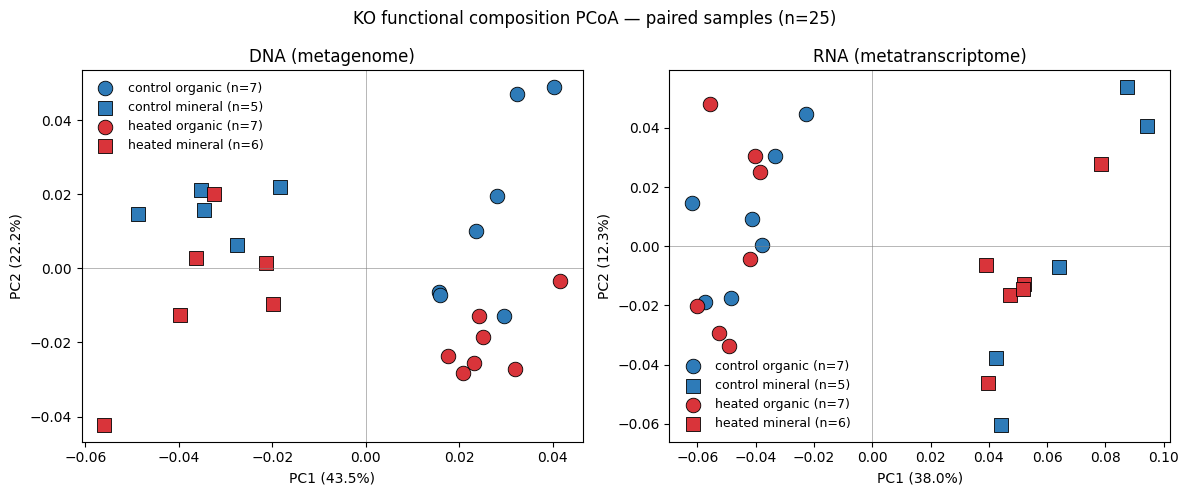

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/04_dna_vs_rna_pcoa.png


In [7]:
def pcoa(D, k=4):
    n = D.shape[0]
    A = -0.5 * D ** 2
    H = np.eye(n) - np.ones((n, n)) / n
    B = H @ A @ H
    w, V = np.linalg.eigh(B)
    idx = np.argsort(-w)
    w = w[idx]
    V = V[:, idx]
    pos = w[:k].clip(min=0)
    coords = V[:, :k] * np.sqrt(pos)
    return coords, w[:k] / w.clip(min=0).sum()

coords_d, var_d = pcoa(D_dna)
coords_r, var_r = pcoa(D_rna)
PCD = pd.DataFrame(coords_d, index=paired, columns=['PC1', 'PC2', 'PC3', 'PC4']).join(paired_meta)
PCR = pd.DataFrame(coords_r, index=paired, columns=['PC1', 'PC2', 'PC3', 'PC4']).join(paired_meta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
color_map = {'control': '#2e7bb8', 'heated': '#d9343a'}
marker_map = {'organic': 'o', 'mineral': 's'}
for ax, df, var, label in [(axes[0], PCD, var_d, 'DNA (metagenome)'),
                            (axes[1], PCR, var_r, 'RNA (metatranscriptome)')]:
    for tx in ['control', 'heated']:
        for hz in ['organic', 'mineral']:
            sub = df[(df['treatment'] == tx) & (df['horizon'] == hz)]
            if not len(sub):
                continue
            ax.scatter(sub['PC1'], sub['PC2'], c=color_map[tx], marker=marker_map[hz],
                       s=110, edgecolors='black', linewidths=0.6,
                       label=f'{tx} {hz} (n={len(sub)})')
    ax.set_xlabel(f'PC1 ({var[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var[1]:.1%})')
    ax.set_title(label)
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.legend(frameon=False, fontsize=9)
plt.suptitle(f'KO functional composition PCoA — paired samples (n={len(paired)})')
plt.tight_layout()
out = os.path.join(FIG_DIR, '04_dna_vs_rna_pcoa.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 5. Centroid distances (treatment effect size in each pool)

Bray-Curtis between Heated centroid and Control centroid, computed within each horizon. Bigger distance → bigger treatment effect.

In [8]:
def centroid(M, idx):
    return M.loc[idx].mean(axis=0)

def bc(u, v):
    return np.abs(u - v).sum() / (u.sum() + v.sum())

def hc_distance(M, meta, hz):
    sub = meta[meta['horizon'] == hz]
    c_idx = sub[sub['treatment'] == 'control'].index
    h_idx = sub[sub['treatment'] == 'heated'].index
    if len(c_idx) < 2 or len(h_idx) < 2:
        return None, len(c_idx), len(h_idx)
    return bc(centroid(M, c_idx), centroid(M, h_idx)), len(c_idx), len(h_idx)

rows = []
for pool, M in [('DNA', DNA), ('RNA', RNA)]:
    for hz in ['organic', 'mineral']:
        d, nc, nh = hc_distance(M, paired_meta, hz)
        rows.append({'pool': pool, 'horizon': hz,
                     'heated_vs_control_centroid_BC': d,
                     'n_control': nc, 'n_heated': nh})
centroid_table = pd.DataFrame(rows)
print(centroid_table.to_string(index=False))

pool horizon  heated_vs_control_centroid_BC  n_control  n_heated
 DNA organic                       0.038498          7         7
 DNA mineral                       0.030584          5         6
 RNA organic                       0.039409          7         7
 RNA mineral                       0.047500          5         6


In [9]:
# Permutation test: is RNA centroid distance > DNA centroid distance, for each horizon?
def perm_compare_distance(DNA, RNA, meta, hz, n_perm=4999, seed=42):
    rng = np.random.default_rng(seed)
    sub_meta = meta[meta['horizon'] == hz].copy()
    samples = sub_meta.index.tolist()
    treats = sub_meta['treatment'].values.copy()
    DNA_h = DNA.loc[samples]
    RNA_h = RNA.loc[samples]
    def stat(treats_):
        c = np.where(treats_ == 'control')[0]
        h = np.where(treats_ == 'heated')[0]
        if len(c) < 2 or len(h) < 2:
            return np.nan
        d_dna = bc(DNA_h.iloc[c].mean(axis=0), DNA_h.iloc[h].mean(axis=0))
        d_rna = bc(RNA_h.iloc[c].mean(axis=0), RNA_h.iloc[h].mean(axis=0))
        return d_rna - d_dna
    obs = stat(treats)
    perm = np.array([stat(rng.permutation(treats)) for _ in range(n_perm)])
    # two-sided p
    p_two = (np.sum(np.abs(perm) >= abs(obs)) + 1) / (n_perm + 1)
    return obs, p_two

rows = []
for hz in ['organic', 'mineral']:
    obs, p = perm_compare_distance(DNA, RNA, paired_meta, hz)
    rows.append({'horizon': hz,
                 'RNA_minus_DNA_centroid_BC': obs,
                 'p_two_sided_perm': p})
delta_table = pd.DataFrame(rows)
print(delta_table.to_string(index=False))

horizon  RNA_minus_DNA_centroid_BC  p_two_sided_perm
organic                   0.000911            0.9990
mineral                   0.016916            0.7658


## 6. Procrustes test (DNA vs RNA configurations)

How well do the DNA and RNA PCoA configurations align across samples? A high `m^2` (residual) and low `correlation` means the two pools see the samples differently.

In [10]:
from scipy.spatial import procrustes
X = PCD[['PC1', 'PC2']].values
Y = PCR.loc[PCD.index][['PC1', 'PC2']].values
_, _, disparity = procrustes(X, Y)
print(f'Procrustes disparity (m^2) on PC1-PC2: {disparity:.4f}')
print(f'(0 = perfectly aligned, 1 = unrelated)')

# Permutation p-value (random label permutations on Y rows)
rng = np.random.default_rng(42)
perm_disp = np.empty(2999)
for k in range(len(perm_disp)):
    Yp = Y[rng.permutation(len(Y))]
    _, _, perm_disp[k] = procrustes(X, Yp)
p_proc = (np.sum(perm_disp <= disparity) + 1) / (len(perm_disp) + 1)
print(f'Procrustes permutation p-value: {p_proc:.4f}')

Procrustes disparity (m^2) on PC1-PC2: 0.4647
(0 = perfectly aligned, 1 = unrelated)
Procrustes permutation p-value: 0.0003


## 7. Save tabular outputs

In [11]:
permanova_table.to_csv(os.path.join(DATA_DIR, '04_permanova_dna_rna.tsv'), sep='\t', index=False)
centroid_table.to_csv(os.path.join(DATA_DIR, '04_centroid_distances.tsv'), sep='\t', index=False)
delta_table.to_csv(os.path.join(DATA_DIR, '04_delta_centroid_perm.tsv'), sep='\t', index=False)
PCD.to_csv(os.path.join(DATA_DIR, '04_pcoa_dna.tsv'), sep='\t')
PCR.to_csv(os.path.join(DATA_DIR, '04_pcoa_rna.tsv'), sep='\t')
print('Saved 5 result tables to data/.')

Saved 5 result tables to data/.


## 8. Summary

**H1 test — does warming shift RNA functional composition more than DNA?**

1. PERMANOVA pseudo-F and R² for treatment compared between DNA and RNA pools (table at top of section 3).
2. Bray-Curtis centroid distance between Heated and Control, per horizon, per pool — direct effect-size comparison.
3. Permutation test on (RNA_centroid_BC − DNA_centroid_BC) per horizon — is the difference significant?
4. Procrustes test on the PC1-PC2 configurations — are DNA and RNA seeing the samples differently?

Read the outputs above for the verdict. Numerical interpretation is captured in the synthesis notebook (NB08) and REPORT.md.